#Arquivo destinado a contagem de nós, extração de dados e produção de subrredes


---


*   Adicione o arquivo da rede clusterizada (`_infomap.xnet`) na pasta ao lado.
*   Em "file_path", insira o caminho do arquivo.
*   É necessária a execução das células abaixo antes dos códigos específicos.


---

In [ ]:
file_path = "/content/WS_subA_infomap.xnet"

---

In [ ]:
import networkx as nx
import pandas as pd
from collections import Counter
from collections import defaultdict
from google.colab import data_table
from google.colab import files
import requests
import re
from tqdm import tqdm
import time

#Leitura do arquivo de rede
with open(file_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

#Etapas de leitura e parsing dos blocos
vertex_labels = []
edges = []
cluster_names = []
abstracts = []
titles = []
wos_ids = []
cluster_indices = []

mode = None

In [ ]:
#Identificação dos blocos
for line in lines:
    stripped = line.strip()
    if stripped.startswith("#vertices"):
        mode = "vertices"
        continue
    elif stripped.startswith("#edges"):
        mode = "edges"
        continue
    elif stripped.startswith('#v "ClusterIndex"'):
        mode = "cluster_index"
        continue
    elif stripped.startswith('#v "ClusterName"'):
        mode = "cluster_name"
        continue
    elif stripped.startswith('#v "abstract"'):
        mode = "abstract"
        continue
    elif stripped.startswith('#v "title"'):
        mode = "title"
        continue
    elif stripped.startswith('#v "wos_id"'):
        mode = "wos_id"
        continue

    if mode == "vertices":
        vertex_labels.append(stripped.strip('"'))
    elif mode == "edges":
        parts = stripped.split()
        if len(parts) == 2:
            u, v = map(int, parts)
            edges.append((u, v))
        elif len(parts) == 3:
            u, v = map(int, parts[:2])
            weight = float(parts[2])
            edges.append((u, v, weight))
    elif mode == "cluster_index":
        cluster_indices.append(int(stripped))
    elif mode == "cluster_name":
        cluster_names.append(stripped.strip('"'))
    elif mode == "abstract":
        abstracts.append(stripped.strip('"'))
    elif mode == "title":
        titles.append(stripped.strip('"'))
    elif mode == "wos_id":
        wos_ids.append(stripped.strip('"'))

#Identificação de nós por cluster
---

Essa seção tem como objetivo extrair o nome dos clusters e seu número de nós.


*   Certifique-se de que `cluster_names` esteja disponível.
*   Em `n_max`, insira o número de clusters que deseja visualizar.

---

In [ ]:
n_max = 10

---

In [ ]:
cluster_name_counts = Counter(cluster_names)

#Contagem do total de nós
node_count = len(cluster_names)

#DataFrame com todos os clusters, ordenados pelo número de nós
df_all_clusters = pd.DataFrame(
    sorted(cluster_name_counts.items(), key=lambda x: (-x[1], x[0])),
    columns=["ClusterName", "Count"]
)

#Configurações de exibição
summary_all = pd.DataFrame([["Total Nodes", node_count]], columns=["ClusterName", "Count"])
df_resultado = pd.concat([summary_all, df_all_clusters], ignore_index=True)

df_top10 = pd.concat([summary_all, df_all_clusters.head(n_max)], ignore_index=True)

data_table.DataTable(df_top10, num_rows_per_page=100)

,ClusterName,Count
0,Total Nodes,41478
1,"A - efficient, electrocatalyst, overall water ...",16505
2,"B - carbon nitride, photocatalytic hydrogen ev...",3114
3,"C - photocatalyst, photocatalysts, visible lig...",2490
4,"D - photoelectrochemical water splitting, arra...",2347
5,"E - two-dimensional, van der waals, photocatal...",1583
6,"F - photoelectrochemical water splitting, sola...",1477
7,"G - photoelectrochemical water splitting, α-fe...",1423
8,"H - device, tandem, solar cell, photoelectroch...",759
9,"I - water oxidation, catalyst, molecular, comp...",553


#Identificação da Centralidade dos nós
---
Essa etapa fornece os nós mais conectados da rede inteira e também de cada cluster.

---

In [ ]:
import pandas as pd
from collections import defaultdict
import networkx as nx
from openpyxl.utils import get_column_letter
from openpyxl.styles import Alignment
from openpyxl import load_workbook

# --- Montagem do grafo e dicionários ---
G = nx.Graph()
G.add_edges_from(edges)

titles_dict = {i: title for i, title in enumerate(titles)}
wos_ids_dict = {i: wos_id for i, wos_id in enumerate(wos_ids)}
cluster_dict = {i: cluster_names[i] for i in range(len(cluster_names))}

# --- Centralidade Global: top 50 ---
degree_global = dict(G.degree())
top_global = sorted(degree_global.items(), key=lambda x: x[1], reverse=True)[:50]

print("Top 50 most connected nodes in the network:\n")
for node, deg in top_global:
    title = titles_dict.get(node, 'no title')
    wos_id = wos_ids_dict.get(node, 'no wos_id')
    print(f"Node {node} (degree = {deg}) - WOS ID: {wos_id} - Title: {title}")

# --- Centralidade por Cluster: top 10 por cluster ---
cluster_degrees = defaultdict(list)
for node in G.nodes():
    cluster = cluster_dict.get(node)
    if cluster is not None:
        cluster_degrees[cluster].append((node, degree_global.get(node, 0)))

print("\nTop 10 most connected nodes per cluster:\n")
for cluster_name in sorted(cluster_degrees.keys()):
    print(f"\nCluster: {cluster_name}")
    top_nodes = sorted(cluster_degrees[cluster_name], key=lambda x: x[1], reverse=True)[:10]
    for node, deg in top_nodes:
        title = titles_dict.get(node, 'no title')
        wos_id = wos_ids_dict.get(node, 'no wos_id')
        print(f"  Node {node} (degree = {deg}) - WOS ID: {wos_id} - Title: {title}")

# --- Preparar DataFrame para os top 50 globais ---
top_global_list = []
for node, deg in top_global:
    top_global_list.append({
        'Node': node,
        'Degree': deg,
        'WOS ID': wos_ids_dict.get(node, 'no wos_id'),
        'Title': titles_dict.get(node, 'no title'),
        'Cluster': cluster_dict.get(node, 'no cluster')
    })
df_global = pd.DataFrame(top_global_list)

# --- Preparar DataFrames para cada cluster (top 10) ---
cluster_dfs = {}
for cluster_name in sorted(cluster_degrees.keys()):
    top_nodes = sorted(cluster_degrees[cluster_name], key=lambda x: x[1], reverse=True)[:10]
    data = []
    for node, deg in top_nodes:
        data.append({
            'Node': node,
            'Degree': deg,
            'WOS ID': wos_ids_dict.get(node, 'no wos_id'),
            'Title': titles_dict.get(node, 'no title')
        })
    cluster_dfs[cluster_name] = pd.DataFrame(data)

# --- Salvar tudo no Excel ---
#excel_filename = 'centrality_results.xlsx'
excel_filename = 'Figure2.xlsx'
with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    df_global.to_excel(writer, sheet_name='Top 50 Global', index=False)
    for cluster_name, df in cluster_dfs.items():
        # Limitar nome da aba a 31 caracteres (limite do Excel)
        safe_name = cluster_name[:31]
        df.to_excel(writer, sheet_name=safe_name, index=False)

wb = load_workbook(excel_filename)

for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]

    # Encontrar índice da coluna "WOS ID" (para definir hyperlink)
    wos_col_idx = None
    for col_idx, cell in enumerate(ws[1], start=1):  # linha 1: cabeçalho
        if cell.value == 'WOS ID':
            wos_col_idx = col_idx
            break

    # Se achou a coluna "WOS ID"
    if wos_col_idx is not None:
        col_letter = get_column_letter(wos_col_idx)
        for row_idx in range(2, ws.max_row + 1):  # começa da 2ª linha, pois 1ª é cabeçalho
            cell = ws[f'{col_letter}{row_idx}']
            wos_id = cell.value
            if wos_id and wos_id != 'no wos_id':
                # Ajustar para o formato hyperlink
                #cell.value = f'=HYPERLINK("{url}", "{wos_id}")'
                cell.value = f'=HYPERLINK("{wos_id}")'

    # Centralizar texto e wrap
    for row in ws.iter_rows(min_row=1, max_row=ws.max_row, min_col=1, max_col=ws.max_column):
        for cell in row:
            cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)

    # Ajustar largura colunas
    for col_idx in range(1, ws.max_column + 1):
        col_letter = get_column_letter(col_idx)
        max_length = 0
        for cell in ws[col_letter]:
            if cell.value:
                # Para fórmulas, cell.value é string com '=' no começo, contar o texto do link
                if isinstance(cell.value, str) and cell.value.startswith('=HYPERLINK'):
                    # Pega o texto do link entre aspas finais
                    try:
                        text = cell.value.split(',')[1].strip().strip('")')
                        max_length = max(max_length, len(text))
                    except:
                        max_length = max(max_length, len(cell.value))
                else:
                    max_length = max(max_length, len(str(cell.value)))
        adjusted_width = (max_length + 2) * 1.2
        ws.column_dimensions[col_letter].width = adjusted_width

    # Ajustar altura linhas
    for row_idx in range(1, ws.max_row + 1):
        ws.row_dimensions[row_idx].height = 30

wb.save(excel_filename)
print(f"\nArquivo '{excel_filename}' salvo com sucesso!")


Top 50 most connected nodes in the network:

Node 0 (degree = 749) - WOS ID: https://openalex.org/W1981983416 - Title: Advances in quantum metrology
Node 1 (degree = 586) - WOS ID: https://openalex.org/W3037089521 - Title: Quantum Metrology
Node 2 (degree = 387) - WOS ID: https://openalex.org/W2767966692 - Title: Quantum metrology with nonclassical states of atomic ensembles
Node 551 (degree = 342) - WOS ID: https://openalex.org/W3037447387 - Title: Quantum sensing
Node 104 (degree = 325) - WOS ID: https://openalex.org/W2007948277 - Title: General framework for estimating the ultimate precision limit in noisy quantum-enhanced metrology
Node 84 (degree = 291) - WOS ID: https://openalex.org/W1993488859 - Title: The elusive Heisenberg limit in quantum-enhanced metrology
Node 3 (degree = 263) - WOS ID: https://openalex.org/W3105676084 - Title: Quantum metrology from a quantum information science perspective
Node 6 (degree = 254) - WOS ID: https://openalex.org/W3039996182 - Title: Photonic 

Essa outra versão fornece a mesma coleta, porém para toda a rede

In [ ]:
import pandas as pd
from openpyxl.utils import get_column_letter
from openpyxl.styles import Alignment
from openpyxl import load_workbook

# --- Montagem do grafo e dicionários ---
G = nx.Graph()
G.add_edges_from(edges)

titles_dict = {i: title for i, title in enumerate(titles)}
wos_ids_dict = {i: wos_id for i, wos_id in enumerate(wos_ids)}

# --- Centralidade Global: TODOS os artigos ---
degree_global = dict(G.degree())

print("Gerando tabela com TODOS os artigos da rede...\n")

all_nodes_list = []
for node in G.nodes():
    all_nodes_list.append({
        'Node': node,
        'Degree': degree_global.get(node, 0),
        'WOS ID': wos_ids_dict.get(node, 'no wos_id'),
        'Title': titles_dict.get(node, 'no title'),
    })

df_all = pd.DataFrame(all_nodes_list)

# Ordenar por grau antes de salvar (opcional)
df_all = df_all.sort_values(by='Degree', ascending=False)

# --- Salvar Excel ---
excel_filename = "Figure2_info.xlsx"

with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    df_all.to_excel(writer, sheet_name='All Articles', index=False)

# --- Ajustar formatação e adicionar hyperlinks ---
wb = load_workbook(excel_filename)
ws = wb['All Articles']

# Encontrar a coluna "WOS ID"
wos_col_idx = None
for col_idx, cell in enumerate(ws[1], start=1):
    if cell.value == 'WOS ID':
        wos_col_idx = col_idx
        break

# Inserir hyperlink
if wos_col_idx is not None:
    col_letter = get_column_letter(wos_col_idx)
    for row_idx in range(2, ws.max_row + 1):
        cell = ws[f'{col_letter}{row_idx}']
        wos_id = cell.value
        if wos_id and wos_id != 'no wos_id':
            cell.value = f'=HYPERLINK("{wos_id}")'

# Estética: centralizar, wrap, ajustar colunas
for row in ws.iter_rows(min_row=1, max_row=ws.max_row,
                        min_col=1, max_col=ws.max_column):
    for cell in row:
        cell.alignment = Alignment(horizontal='center',
                                   vertical='center',
                                   wrap_text=True)

# Ajustar larguras das colunas
for col_idx in range(1, ws.max_column + 1):
    col_letter = get_column_letter(col_idx)
    max_length = 0
    for cell in ws[col_letter]:
        v = str(cell.value) if cell.value else ""
        if v.startswith('=HYPERLINK'):
            try:
                v = v.split(',')[1].strip().strip('")')
            except:
                pass
        max_length = max(max_length, len(v))
    ws.column_dimensions[col_letter].width = (max_length + 2) * 1.2

# Ajustar altura das linhas
for row_idx in range(1, ws.max_row + 1):
    ws.row_dimensions[row_idx].height = 30

wb.save(excel_filename)
print(f"\nArquivo '{excel_filename}' salvo com sucesso!")

Gerando tabela com TODOS os artigos da rede...


Arquivo 'Figure2_info.xlsx' salvo com sucesso!


#Produção de sub-redes

---

Na célula abaixo, em `cname.startswith("_")`, insira o cluster desejado

**Ex:**

Se deseja uma sub-rede do cluster A, então:


*   `NEW_nodes = [i for i, cname in enumerate(cluster_names) if cname.startswith("A")]`

---

In [ ]:
#Identificação dos índices dos nós de interesse
NEW_nodes = [i for i, cname in enumerate(cluster_names) if cname.startswith("A")]

In [ ]:
#Mapeamento antigo índice → novo índice
index_mapping = {old: new for new, old in enumerate(NEW_nodes)}

#Filtro das arestas internas do Cluster
if len(parts) == 2:
  NEW_edges = [(index_mapping[u], index_mapping[v]) for u, v in edges if u in index_mapping and v in index_mapping]
elif len(parts) == 3:
  NEW_edges = [
    (index_mapping[u], index_mapping[v], w)
    for u, v, w in edges
    if u in index_mapping and v in index_mapping
]

#Dados filtrados
NEW_titles = [titles[i] for i in NEW_nodes]
NEW_abstracts = [abstracts[i] for i in NEW_nodes]
NEW_wos_ids = [wos_ids[i] for i in NEW_nodes]

In [ ]:
#Caminho para salvar a sub-rede - Altere o nome se necessário
output_path = "/content/WS_subA_subA.xnet"

#Inserção dos dados na sub-rede
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(f"#vertices {len(NEW_nodes)}\n")
    for label in NEW_wos_ids:
        f.write(f'"{label}"\n')

    f.write("#edges nonweighted undirected\n")

    if len(parts) == 2:
      for u, v in NEW_edges:
          f.write(f"{u} {v}\n")
    elif len(parts) == 3:
      for u, v, w in NEW_edges:
          f.write(f"{u} {v} {w}\n")

    f.write('#v "abstract" s\n')
    for abs_txt in NEW_abstracts:
        f.write(f'"{abs_txt}"\n')

    f.write('#v "title" s\n')
    for title in NEW_titles:
        f.write(f'"{title}"\n')

print(f"Arquivo .xnet da sub-rede gerada em: {output_path}")
print(f'Número de nós da sub-rede: {len(NEW_nodes)}')


Arquivo .xnet da sub-rede gerada em: /content/WS_subA_subA.xnet
Número de nós da sub-rede: 16505


#Coleta de dados Textuais

---

As células abaixo são destinadas a extrair os links, títulos e resumos dos artigos da sub-rede produzido anteriormente, assim como inserir seus dados em um arquixo `.dat` ou `.xlsx`

In [ ]:
output_infos_dat = "/content/Subnetwork_infos.dat"
output_infos_xlsx = "/content/Subnetwork_infos.xlsx"

with open(output_infos_dat, 'w', encoding='utf-8') as f:

    for label in NEW_wos_ids:
        f.write(f'"{label}"\n')

    for title in NEW_titles:
        f.write(f'"{title}"\n')

    for abs_txt in NEW_abstracts:
        f.write(f'"{abs_txt}"\n')

openalex_base_url = "https://openalex.org/works/"
hyperlinks = [f'=HYPERLINK("{wos_id}")' for wos_id in NEW_wos_ids]

df = pd.DataFrame({
    "link on OpenAlex": hyperlinks,
    "Title": NEW_titles,
    "Abstract": NEW_abstracts
})

df.to_excel(output_infos_xlsx, index=False)

print(f"Arquivo .dat contendo as informações da sub-rede gerada em: {output_infos_dat}")
print(f"Arquivo .xlsx contendo as informações da sub-rede gerada em: {output_infos_xlsx}")

In [ ]:
!pip install igraph
import igraph as ig

# --- Prepara as arestas para o grafo ---
edges_clean = []   # só os pares (u, v)
weights = []       # pesos opcionais

for e in edges:
    if len(e) == 2:
        edges_clean.append(e)        # adiciona aresta simples
        weights.append(1.0)         # peso default, se quiser
    elif len(e) == 3:
        edges_clean.append(e[:2])    # só os dois primeiros elementos como aresta
        weights.append(e[2])        # guarda o peso

# --- Cria o grafo ---
net = ig.Graph()
net.add_vertices(len(vertex_labels))   # adiciona todos os vértices
net.vs['name'] = vertex_labels        # atribui nomes aos vértices
net.add_edges(edges_clean)            # adiciona as arestas

# Se houver pesos, adiciona como atributo
net.es['weight'] = weights

# --- Identifica os componentes conectados ---
components = net.clusters()           # retorna todos os componentes

# --- Seleciona o maior componente ---
giant = components.giant()

# --- Número de nós do maior componente ---
num_nodes_giant = giant.vcount()
print("Número de nós do maior componente:", num_nodes_giant)

#Construção de dados, tabelas e planilhas
---

In [ ]:
#import requests
#import time

#def get_year_openalex(work_id):
#    url = f"https://api.openalex.org/works/{work_id}"
#    r = requests.get(url)
#    if r.status_code == 200:
#        return r.json().get("publication_year", "")
#    return ""

#years = []
#for wos in tqdm(wos_ids, desc="Buscando anos"):
#    year = get_year_openalex(wos)
#    years.append(year)
#    time.sleep(0.1)  # evita rate limit

def get_year_openalex(work_url):
    work_id = work_url.strip().split("/")[-1]
    url = f"https://api.openalex.org/works/{work_id}"
    r = requests.get(url)
    if r.status_code == 200:
        return r.json().get("publication_year", None)
    return None

years = []
for wos in tqdm(wos_ids, desc="Buscando anos"):
    year = get_year_openalex(wos)
    years.append(year)
    time.sleep(0.1)

In [ ]:
output_dat = "/content/anos_publicacao.dat"

with open(output_dat, "w", encoding="utf-8") as f:
    f.write("# OpenAlex_ID\tPublication_Year\n")
    for wos, year in zip(wos_ids, years):
        year_str = str(year) if year is not None else ""
        f.write(f"{wos}\t{year_str}\n")

print(f"✅ Arquivo salvo em: {output_dat}")

✅ Arquivo salvo em: /content/anos_publicacao.dat


In [ ]:
import pandas as pd
import re
from tqdm import tqdm
from openpyxl.utils import get_column_letter
from openpyxl.styles import Alignment, PatternFill, Font, Border, Side
from openpyxl import load_workbook
from openpyxl.chart import BarChart, Reference
from openpyxl.chart.label import DataLabelList
from openpyxl.chart.axis import ChartLines
import time

# =====================================
# CONFIGURAÇÕES
# =====================================
output_excel = "/content/Comunidades_Artigos.xlsx"
n_top_clusters = 10  # número de clusters a exportar
# =====================================

# Preparação dos dados
data = []
for title, wos, cluster, year in zip(titles, wos_ids, cluster_names, years):
    if not title.strip() or not wos.strip():
        continue
    else:
        link = wos
    data.append({"ClusterName": cluster, "Título": title, "Ano": year, "Link": link})

df_full = pd.DataFrame(data)

# Clusters mais relevantes
cluster_counts = df_full["ClusterName"].value_counts()
top_clusters = cluster_counts.head(n_top_clusters).index.tolist()
print(f"Exportando os {len(top_clusters)} clusters mais relevantes...")

# Palavras-chave simuladas (substitua pelo seu método real)
keywords_dict = {cluster: ", ".join(cluster.lower().split()[:10]) for cluster in top_clusters}

def sanitize_sheet_name(name):
    name = re.sub(r'[\\/*?:\[\]]', '_', str(name))
    return name[:31]

# =====================================
# FASE 1 — CRIAÇÃO DAS PLANILHAS
# =====================================
with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:

    # ABA RESUMO
    summary_data = []
    for i, cluster in enumerate(top_clusters):
        count = len(df_full[df_full["ClusterName"] == cluster])
        summary_data.append({
            "Comunidade": chr(65 + i),
            "Número de Artigos": count
        })
    df_summary = pd.DataFrame(summary_data)

    # Texto instrutivo
    instructions = [
        ["📘 COMO USAR ESTE ARQUIVO:"],
        [(
            "Cada aba neste arquivo representa uma comunidade de artigos identificado na Rede de Similaridade.\n"
            "- A coluna 'Título' lista os artigos da comunidade.\n"
            "- A coluna 'Link' fornece acesso direto ao artigo no OpenAlex.\n"
            "A tabela abaixo resume as comunidades e o número de artigos em cada uma delas.\n"
            "O gráfico mostra visualmente a quantidade de artigos por comunidade.\n"
        )]
    ]
    df_instr = pd.DataFrame(instructions, columns=["Instruções"])
    df_instr.to_excel(writer, sheet_name="Resumo", index=False, startrow=0)
    df_summary.to_excel(writer, sheet_name="Resumo", index=False, startrow=3)

    # Planilhas de clusters
    for cluster in tqdm(top_clusters, desc="Gerando planilhas"):
        df_cluster = df_full[df_full["ClusterName"] == cluster][["Título", "Link", "Ano"]].reset_index(drop=True)
        sheet_name = sanitize_sheet_name(cluster)
        df_cluster.to_excel(writer, sheet_name=sheet_name, index=False)

time.sleep(1)

# =====================================
# FASE 2 — FORMATAÇÃO DO EXCEL
# =====================================
wb = load_workbook(output_excel)

# Estilos
header_fill = PatternFill(start_color="BDD7EE", end_color="BDD7EE", fill_type="solid")
header_font = Font(bold=True, color="000000")
thin_border = Border(
    left=Side(style="thin"),
    right=Side(style="thin"),
    top=Side(style="thin"),
    bottom=Side(style="thin")
)
center_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
left_alignment = Alignment(horizontal="left", vertical="top", wrap_text=True)
fill_odd = PatternFill(start_color="FFFFFF", end_color="FFFFFF", fill_type="solid")
fill_even = PatternFill(start_color="F2F2F2", end_color="F2F2F2", fill_type="solid")

# =====================================
# ABA RESUMO
# =====================================
ws_sum = wb["Resumo"]

# Ajuste da célula título (A1) com fundo colorido
ws_sum.merge_cells("A1:B1")
ws_sum["A1"].font = Font(bold=True, size=14, color="FFFFFF")  # texto branco
ws_sum["A1"].alignment = center_alignment
ws_sum["A1"].fill = PatternFill(start_color="4F81BD", end_color="4F81BD", fill_type="solid")  # azul
ws_sum.row_dimensions[1].height = 25


# Ajuste células A2 e A3
ws_sum.merge_cells("A2:B2")
ws_sum["A2"].alignment = left_alignment
ws_sum.row_dimensions[2].height = ws_sum.row_dimensions[5].height  # A2 igual altura A5

ws_sum.merge_cells("A3:B3")
ws_sum["A3"].alignment = left_alignment
ws_sum.row_dimensions[3].height = 100  # tamanho antigo da A2

# Cabeçalho tabela
header_row = 4
for cell in ws_sum[header_row]:
    cell.fill = header_fill
    cell.font = header_font
    cell.alignment = center_alignment
    cell.border = thin_border
ws_sum.row_dimensions[header_row].height = 25

# Corpo tabela com efeito zebra
for i, row in enumerate(ws_sum.iter_rows(min_row=header_row + 1, max_row=header_row + len(top_clusters))):
    fill = fill_odd if i % 2 == 0 else fill_even
    for cell in row:
        cell.alignment = center_alignment
        cell.border = thin_border
        cell.fill = fill
        ws_sum.row_dimensions[cell.row].height = 25


# Ajustar largura colunas
for col in ws_sum.columns:
    ws_sum.column_dimensions[get_column_letter(col[0].column)].width = 40

# =====================================
# GRÁFICO REVISADO — ABA RESUMO
# =====================================

# Gráfico revisado
chart = BarChart()
chart.type = "col"
chart.title = "Número de Artigos por Comunidade"
chart.y_axis.title = "Número de artigos"
chart.x_axis.title = "Comunidades"
chart.legend = None  # remove legenda
chart.height = 8
chart.width = 15

# Dados: apenas valores, sem título
data = Reference(ws_sum, min_col=2, min_row=header_row + 1, max_row=header_row + len(top_clusters))
chart.add_data(data, titles_from_data=False)  # títulos = False evita criar "Série 1"

# Categorias: letras dos clusters
cats = Reference(ws_sum, min_col=1, min_row=header_row + 1, max_row=header_row + len(top_clusters))
chart.set_categories(cats)

# Rótulos: apenas números, acima da barra
chart.dLbls = DataLabelList()
chart.dLbls.showVal = True       # mostra apenas o número
chart.dLbls.showCatName = False  # não mostra categoria
chart.dLbls.showSerName = False  # não mostra título da série
chart.dLbls.position = "outEnd"

# Linhas de grade no eixo Y
chart.y_axis.majorGridlines = ChartLines()

# Inserir gráfico
ws_sum.add_chart(chart, "D5")

# =====================================
# ABAS DE CLUSTERS COM ZEBRA, BORDAS E CENTRALIZAÇÃO FINAL
# =====================================
for sheet_name in wb.sheetnames:
    if sheet_name == "Resumo":
        continue
    ws = wb[sheet_name]

    # Cabeçalho
    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = center_alignment
        cell.border = thin_border

    # Altura das linhas: Title e Link = 2/3 altura anterior
    ws.row_dimensions[1].height = 30
    for r in range(2, ws.max_row + 1):
        ws.row_dimensions[r].height = 50

    # Bordas, alinhamento e efeito zebra em todas as células
    for i, row in enumerate(ws.iter_rows(min_row=2, max_row=ws.max_row)):
        fill = fill_odd if i % 2 == 0 else fill_even
        for cell in row:
            cell.alignment = center_alignment
            cell.border = thin_border
            cell.fill = fill

    # Links clicáveis e centralizados na coluna B
    for row in range(2, ws.max_row + 1):
        link_cell = ws[f"B{row}"]
        link = link_cell.value
        if isinstance(link, str) and link.startswith("http"):
            link_cell.hyperlink = link
            link_cell.style = "Hyperlink"
            link_cell.alignment = center_alignment
            link_cell.border = thin_border
            link_cell.fill = fill_odd if (row-2) % 2 == 0 else fill_even

    # Ajuste largura automática
    for col in ws.columns:
        max_length = 0
        column = get_column_letter(col[0].column)
        for cell in col:
            if cell.value:
                max_length = max(max_length, len(str(cell.value)))
        ws.column_dimensions[column].width = min(max_length + 5, 80)

# =====================================
# SALVAR ARQUIVO FINAL
# =====================================
wb.save(output_excel)
wb.close()

print(f"\n✅ Arquivo Excel final, totalmente formatado e refinado salvo em: {output_excel}")

Exportando os 7 clusters mais relevantes...


Gerando planilhas: 100%|██████████| 7/7 [00:00<00:00, 260.35it/s]



✅ Arquivo Excel final, totalmente formatado e refinado salvo em: /content/Comunidades_Artigos.xlsx


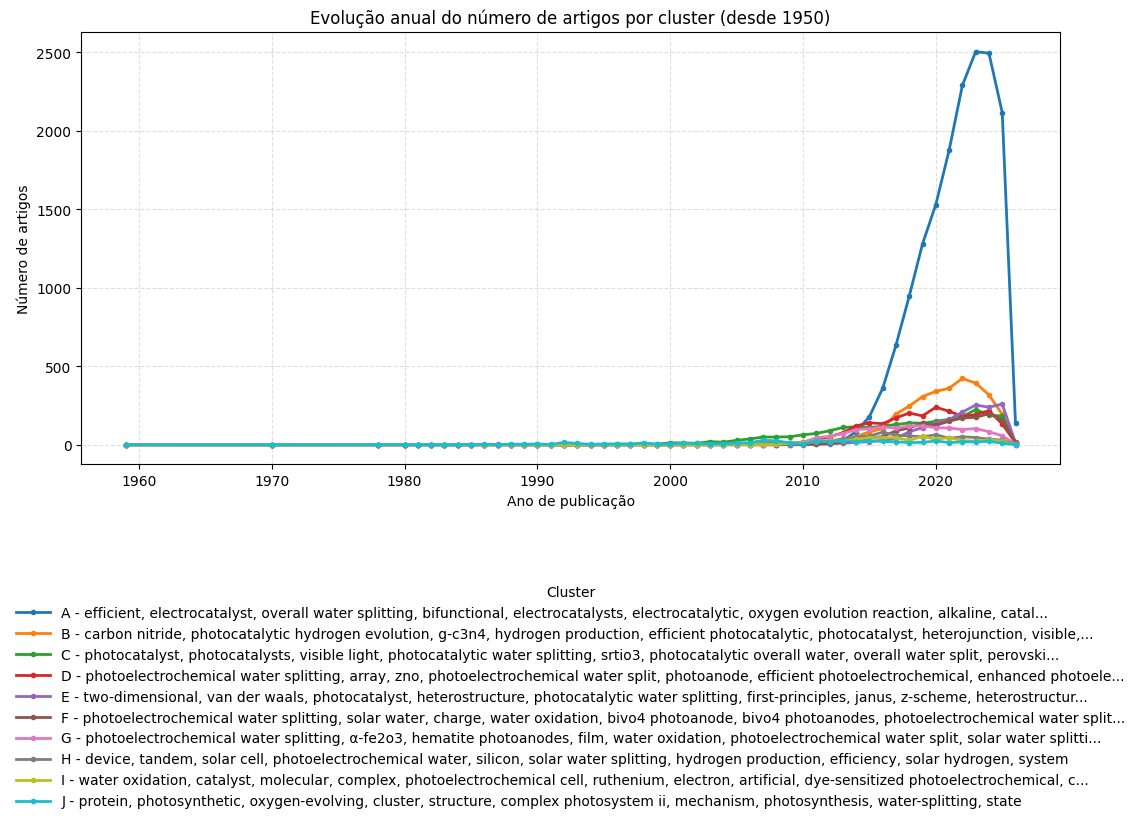

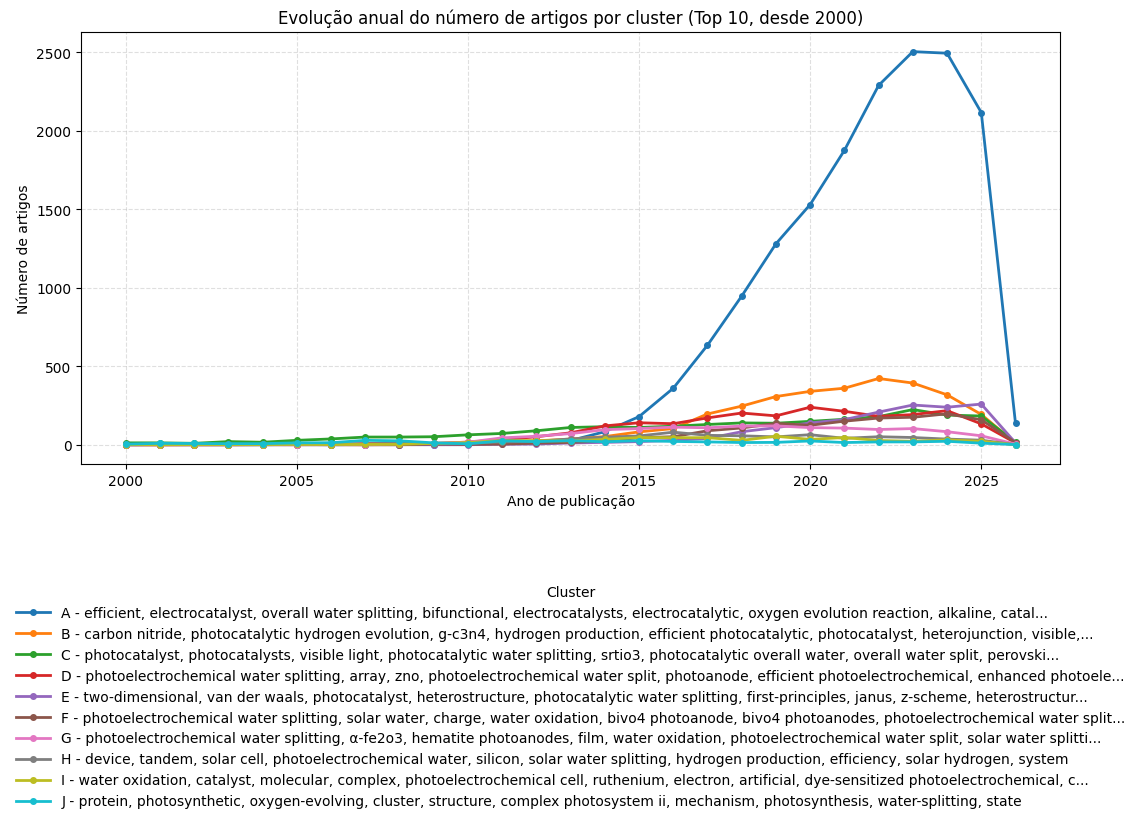

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# CONFIGURAÇÕES
# ===============================
n_top_clusters = 10
figsize = (12, 9)
ano_minimo = 1950

# ===============================
# SELEÇÃO DOS TOP 10 CLUSTERS
# ===============================
cluster_counts = df_full["ClusterName"].value_counts()
top_clusters = cluster_counts.head(n_top_clusters).index.tolist()

df_top = df_full[df_full["ClusterName"].isin(top_clusters)].copy()

# ===============================
# LIMPEZA DA COLUNA ANO
# ===============================

# Remove NaN, None e strings vazias
df_top = df_top[df_top["Ano"].notna()]
df_top = df_top[df_top["Ano"].astype(str).str.strip() != ""]

# Converte para numérico (erros viram NaN)
df_top["Ano"] = pd.to_numeric(df_top["Ano"], errors="coerce")

# Remove valores inválidos após conversão
df_top = df_top[df_top["Ano"].notna()]

# Mantém apenas anos >= 1950
df_top = df_top[df_top["Ano"] >= ano_minimo]

# Garante tipo inteiro
df_top["Ano"] = df_top["Ano"].astype(int)

# ===============================
# AGREGAÇÃO: ARTIGOS POR ANO × CLUSTER
# ===============================
df_year_cluster = (
    df_top
    .groupby(["Ano", "ClusterName"])
    .size()
    .reset_index(name="N_Artigos")
)

# ===============================
# PIVOT PARA FORMATO DE SÉRIE TEMPORAL
# ===============================
df_pivot = (
    df_year_cluster
    .pivot(index="Ano", columns="ClusterName", values="N_Artigos")
    .fillna(0)
    .sort_index()
)

# ===============================
# GRÁFICO 1 — DESDE 1950
# ===============================
plt.figure(figsize=figsize)

for cluster in df_pivot.columns:
    plt.plot(
        df_pivot.index,
        df_pivot[cluster],
        marker="o",
        markersize=3,
        linewidth=2,
        label=cluster
    )

plt.xlabel("Ano de publicação")
plt.ylabel("Número de artigos")
plt.title("Evolução anual do número de artigos por cluster (desde 1950)")
plt.grid(True, which="both", axis="both", linestyle="--", alpha=0.4)
plt.legend(
    title="Cluster",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=1,                 # <<< uma única coluna
    frameon=False,
    handlelength=2.5,
    columnspacing=1.5
)

plt.tight_layout()
plt.show()


# ===============================
# GRÁFICO 2 — DESDE 2000
# ===============================
df_pivot_2000 = df_pivot[df_pivot.index >= 2000]

plt.figure(figsize=figsize)

for cluster in df_pivot_2000.columns:
    plt.plot(
        df_pivot_2000.index,
        df_pivot_2000[cluster],
        marker="o",
        markersize=4,
        linewidth=2,
        label=cluster
    )

plt.xlabel("Ano de publicação")
plt.ylabel("Número de artigos")
plt.title("Evolução anual do número de artigos por cluster (Top 10, desde 2000)")
plt.grid(True, which="both", axis="both", linestyle="--", alpha=0.4)

plt.legend(
    title="Cluster",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=1,                 # <<< uma única coluna
    frameon=False,
    handlelength=2.5,
    columnspacing=1.5
)

plt.tight_layout()
plt.show()





In [ ]:
import pandas as pd

s = pd.Series(years)
print("Sem ano:", s.isna().sum() + (s == "").sum())
print("Total:", len(s))
print(year)


Sem ano: 1
Total: 41478
2019
